In [2]:
!pip install geopandas folium scikit-learn scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 11.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 9.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [folium]2m5/6 [folium]as]


In [6]:
import json
import numpy as np
import pandas as pd
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt

# Load data
with open("dublin_ev_chargers.geojson") as f:
    raw = json.load(f)

stations = [f["properties"] | {
    "lat": f["geometry"]["coordinates"][1],
    "lon": f["geometry"]["coordinates"][0]
} for f in raw["features"]]

df = pd.DataFrame(stations)
print(f"Total stations: {len(df)}")
df.head()

Total stations: 133


,id,lat,lon,address,operator,num_chargers,source_area,open_hours
0,esb_0,53.611523,-6.182852,"Irish Rail, Railway Street, Balbriggan",ESB eCars,1,ESB_national,24 x 7
1,esb_1,53.310296,-6.195844,"Irish Rail Booterstown DART Station, Rock Road...",ESB eCars,1,ESB_national,24 x 7
2,esb_2,53.302596,-6.178974,"Irish Rail Blackrock DART Station, Bath Place,...",ESB eCars,1,ESB_national,24 x 7
3,esb_3,53.360629,-6.299333,"Tesco Cabra, Navan Road, Northside, Cabra",ESB eCars,1,ESB_national,24 x 7
4,esb_4,53.251009,-6.185082,"Carrickmines Park,Glenamuck road, Carrickmines",ESB eCars,1,ESB_national,24 x 7


In [7]:
# Station Distribution Map
COLORS = {
    "ESB eCars": "green",
    "EasyGo": "blue",
    "Tesla": "red",
    "ESB": "darkgreen",
    "Other": "gray"
}

m = folium.Map(location=[53.34, -6.27], zoom_start=11)

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=4 + row["num_chargers"] * 2,
        color=COLORS.get(row["operator"], "gray"),
        fill=True,
        fill_opacity=0.8,
        popup=f"<b>{row['address']}</b><br>{row['operator']}<br>{row['num_chargers']} charger(s)"
    ).add_to(m)

legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:999;
     background:white;padding:10px 14px;border-radius:8px;
     border:1px solid #ccc;font-size:13px;line-height:1.8;">
  <b>Operator</b><br>
  <span style="color:green">●</span> ESB eCars<br>
  <span style="color:blue">●</span> EasyGo<br>
  <span style="color:red">●</span> Tesla<br>
  <span style="color:darkgreen">●</span> ESB<br>
  <span style="color:gray">●</span> Other<br>
  <i style="font-size:11px">Circle size = no. of chargers</i>
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

m  # renders in notebook

In [8]:
# Coverage Heatmap
heat_data = [[row["lat"], row["lon"], row["num_chargers"]]
             for _, row in df.iterrows()]

m2 = folium.Map(location=[53.34, -6.27], zoom_start=11)
HeatMap(heat_data, radius=25, blur=20, min_opacity=0.4).add_to(m2)

m2

In [13]:
!pip install contextily geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 6.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [contextily]7 [rasterio]


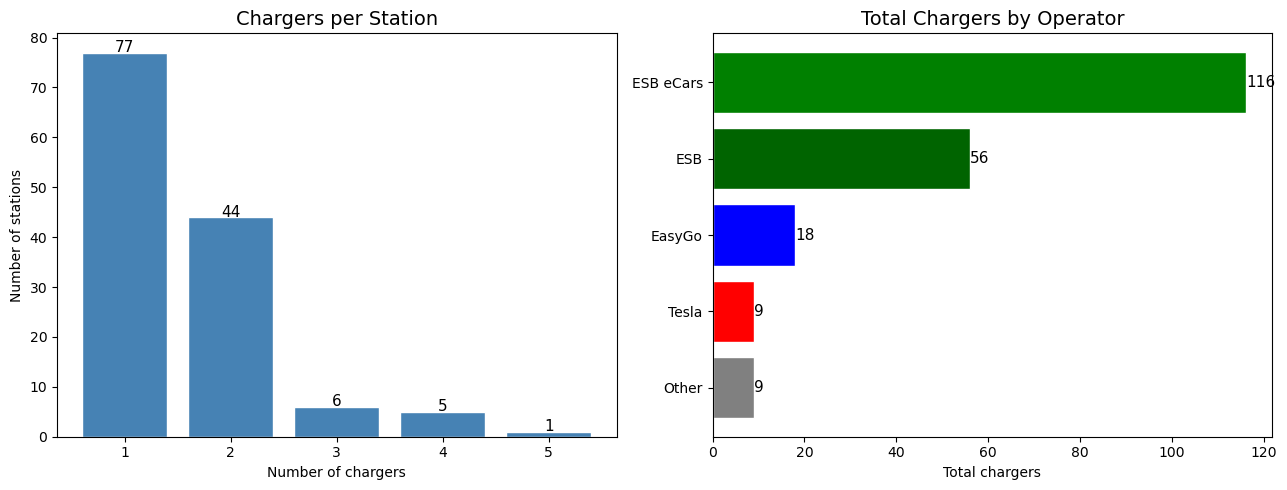

In [9]:
# Number of Chargers per Station
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: charger count frequency
counts = df["num_chargers"].value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white")
axes[0].set_title("Chargers per Station", fontsize=14)
axes[0].set_xlabel("Number of chargers")
axes[0].set_ylabel("Number of stations")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.1, str(v), ha="center", fontsize=11)

# Bar chart: total chargers by operator
op_total = df.groupby("operator")["num_chargers"].sum().sort_values(ascending=True)
colors = [COLORS.get(op, "gray") for op in op_total.index]
axes[1].barh(op_total.index, op_total.values, color=colors, edgecolor="white")
axes[1].set_title("Total Chargers by Operator", fontsize=14)
axes[1].set_xlabel("Total chargers")
for i, v in enumerate(op_total.values):
    axes[1].text(v + 0.1, i, str(v), va="center", fontsize=11)

plt.tight_layout()
plt.savefig("ev_chargers_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

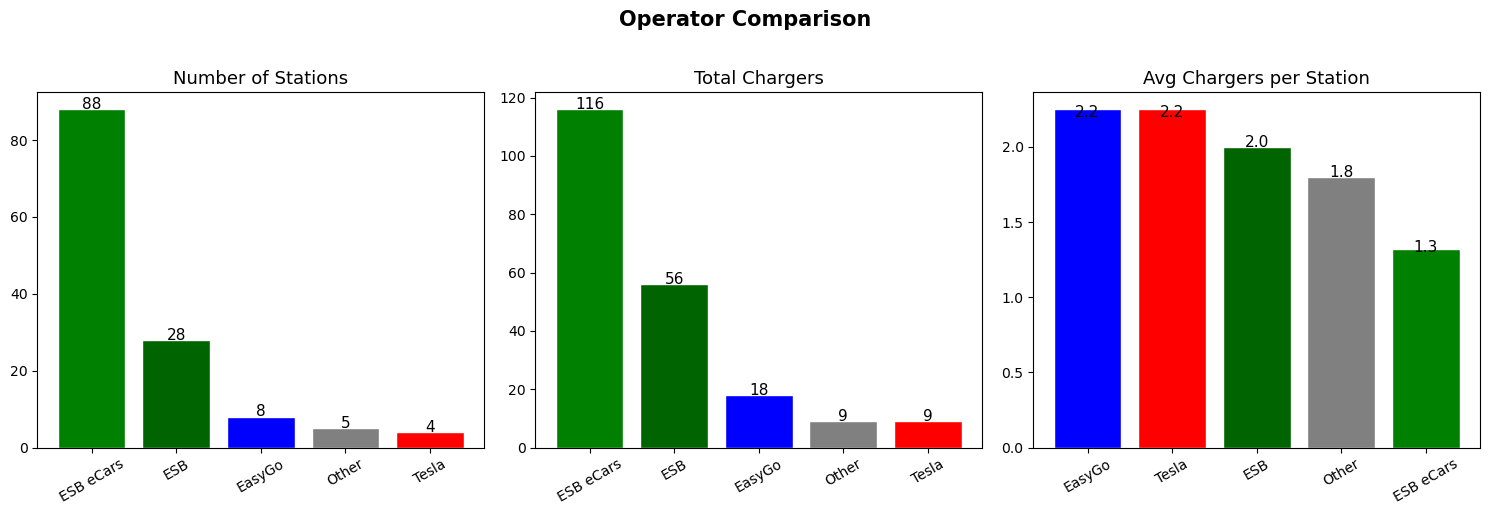

In [10]:
# Operator Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Number of stations per operator
op_stations = df["operator"].value_counts()
axes[0].bar(op_stations.index, op_stations.values,
            color=[COLORS.get(op, "gray") for op in op_stations.index],
            edgecolor="white")
axes[0].set_title("Number of Stations", fontsize=13)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(op_stations.values):
    axes[0].text(i, v + 0.1, str(v), ha="center", fontsize=11)

# Total chargers per operator
op_total = df.groupby("operator")["num_chargers"].sum().sort_values(ascending=False)
axes[1].bar(op_total.index, op_total.values,
            color=[COLORS.get(op, "gray") for op in op_total.index],
            edgecolor="white")
axes[1].set_title("Total Chargers", fontsize=13)
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(op_total.values):
    axes[1].text(i, v + 0.1, str(v), ha="center", fontsize=11)

# Avg chargers per station
op_avg = df.groupby("operator")["num_chargers"].mean().sort_values(ascending=False)
axes[2].bar(op_avg.index, op_avg.values,
            color=[COLORS.get(op, "gray") for op in op_avg.index],
            edgecolor="white")
axes[2].set_title("Avg Chargers per Station", fontsize=13)
axes[2].tick_params(axis="x", rotation=30)
for i, v in enumerate(op_avg.values):
    axes[2].text(i, round(v, 1), f"{v:.1f}", ha="center", fontsize=11)

plt.suptitle("Operator Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("operator_comparison.png", dpi=150, bbox_inches="tight")
plt.show()